# Difference in conventions from bbhx

**1. reference phase**

The reference phase is a convention used to fix the freedom of an arbitrary constant phase shift in the waveform, which corresponds to an arbitrary rotation of the binary system.

In `pespace`, we use waveforms generated following the convention of `lalsimulation` (see Appendix C in [2001.10914](https://arxiv.org/abs/2001.10914) for more details). While in `bbhx`, waveforms are generated with $\phi_\mathrm{ref}=0$ (see [l.521 in bbhx/waveformbuild.py](https://github.com/mikekatz04/BBHx/blob/9176bc143b1a2ed0021ae326448ef33958e03676/bbhx/waveformbuild.py#L521)), the rotation is applied latter through the spin-weighted spherical harmonics in the computation of the response (see [l.556 in bbhx/waveformbuild.py](https://github.com/mikekatz04/BBHx/blob/9176bc143b1a2ed0021ae326448ef33958e03676/bbhx/waveformbuild.py#L556) and [l.582-583 in bbhx/cutils/src/Response.cu](https://github.com/mikekatz04/BBHx/blob/9176bc143b1a2ed0021ae326448ef33958e03676/bbhx/cutils/src/Response.cu#L582-L583)). 

To obtain the same output, using $\phi^\mathrm{bbhx}_\mathrm{ref} = \pi/2 - \phi^\mathrm{pespace}_\mathrm{ref}$ as the input parameter.

**2. Fourier transformation**

To ensure the positive azimuthal modes are concentrated in the positive frequency branch, `bbhx` adopts a Fourier transform convention with the opposite sign to the commonly used one (see appendix A in [1806.10734](https://arxiv.org/abs/1806.10734)). 

While `pespace` uses the conventional definition of the Fourier transform. Thus there is a difference of global complex conjugation. It need to be noted that the waveform inputted also need to be conjugated accordingly.

**3. Unit vectors of the constellation** (potential bug?? # TODO)

The unit vector of each link is computed in [l.101-127 in bbhx/cutils/src/Response.cu](https://github.com/mikekatz04/BBHx/blob/9176bc143b1a2ed0021ae326448ef33958e03676/bbhx/cutils/src/Response.cu#L101-L127), where `n1` is obtained by `orbits->get_normal_unit_vec(t, 12)`, giving the vector between nodes 1 and 2. While in the computation of terms involving `sinc` and $\boldsymbol{n}_l \cdot \boldsymbol{H} \cdot \boldsymbol{n}_l$ ([l.175-191](https://github.com/mikekatz04/BBHx/blob/9176bc143b1a2ed0021ae326448ef33958e03676/bbhx/cutils/src/Response.cu#L175-L191)), `n1` is treated as the vector between nodes 2 and 3. Here we rigidly follow the computation in bbhx to verify whether remaining parts are all consistent, and leave this issue for future checks.



In [1]:
import copy

import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

import taichi as ti
ti.init(
    arch=ti.cpu,
    default_fp=ti.f64,
    cpu_max_num_threads=1,
    offline_cache=False,
    debug=True,
)

from pespace.detector.antenna import InterferometerAntenna, FDResponseModelMarset2018
from pespace.detector.tdi import TDIChannelData, FDMichelsonConstantEqualArm
from pespace.detector.orbit import KaplerianHeliocentric
from tiwave.waveforms import IMRPhenomXAS

from bbhx.response.fastfdresponse import LISATDIResponse
from bbhx.waveformbuild import BBHWaveformFD
from  bbhx.waveforms.phenomhm import PhenomHMAmpPhase
import lal
import bilby

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.19
[Taichi] Starting on arch=x64


[I 02/05/26 15:53:45.322 196071] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


No CuPy or GPU response available.
No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.


/tmp/ipykernel_196071/3853856849.py:24: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
f_ref = 1e-4
f_min = 1e-4
f_max = 0.1
t_start = 0.0

channels = ("A", "E", "T")
delta_time = 5
num_tsamples = 2 ** np.ceil(np.log2(4 * lal.DAYJUL_SI / delta_time))
duration = num_tsamples * delta_time
print("sample num: ", num_tsamples)
print("duration: ", duration)

tdi_data = TDIChannelData()
tdi_data.set_fd_data_from_zero(
    channels,
    duration,
    delta_time,
    start_time=t_start,
    minimum_frequency=f_min,
    maximum_frequency=f_max,
)


sample num:  131072.0
duration:  655360.0


In [3]:
params = dict(
    total_mass=3e6,
    mass_ratio=0.6,
    chi_1=0.75,
    chi_2=0.62,
    luminosity_distance=56000.0,
    inclination=0.4,
    reference_phase=1.3,
    ecliptic_longitude=1.375,
    ecliptic_latitude=-1.2108,
    polarization=2.659,
    coalescence_time=0.0,
)
params = bilby.gw.conversion.generate_mass_parameters(params)
print(params)

waveform_tiw = IMRPhenomXAS(tdi_data.frequency_samples, f_ref)
waveform_tiw.update_waveform(params)
f_peak_Hz = waveform_tiw.amplitude_coefficients[None].f_peak / waveform_tiw.source_parameters[None].M_sec  # fmt: skip
print("peak around (Hz): ", f_peak_Hz)

waveform_tiw = IMRPhenomXAS(tdi_data.frequency_samples, f_peak_Hz)
waveform_tiw.update_waveform(params)


{'total_mass': 3000000.0, 'mass_ratio': 0.6, 'chi_1': 0.75, 'chi_2': 0.62, 'luminosity_distance': 56000.0, 'inclination': 0.4, 'reference_phase': 1.3, 'ecliptic_longitude': 1.375, 'ecliptic_latitude': -1.2108, 'polarization': 2.659, 'coalescence_time': 0.0, 'mass_1': 1875000.0, 'mass_2': 1125000.0, 'chirp_mass': 1256226.717491785, 'symmetric_mass_ratio': np.float64(0.234375)}


/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/base_waveform.py:69: UserWarning: check_parameters is disable, make sure all parameters passed in are valid.
  warnings.warn(


peak around (Hz):  0.006847819521032306


### make up a fake signal for comparision

In [4]:
amp = np.ones(tdi_data.data_info.frequency_series_length)
phi = np.zeros(tdi_data.data_info.frequency_series_length)
tf = np.ones(tdi_data.data_info.frequency_series_length)
h22 = amp * np.exp(1j * phi)

from tiwave.utils import ti_complex
harm_fac = ti.Struct.field({"plus": ti_complex, "cross": ti_complex}, shape=())
@ti.kernel
def compute_harmonic_factors():
    waveform_tiw.source_parameters[None].update_source_parameters(
        params["mass_1"],
        params["mass_2"],
        params["chi_1"],
        params["chi_2"],
        params["luminosity_distance"],
        params["inclination"],
        params["reference_phase"],
        f_ref,
    )
    waveform_tiw._set_harmonic_factors(harm_fac[None])  # depending the iota
compute_harmonic_factors()
harm_fac_np = harm_fac.to_numpy()

hp = harm_fac_np["plus"].view(np.complex128) * h22
hc = harm_fac_np["cross"].view(np.complex128) * h22
# hp = -1 * 0.125 * np.sqrt(5 / np.pi) * (1 + np.cos(params["inclination"]) ** 2) * h22
# hc = 1j * 0.125 * np.sqrt(5 / np.pi) * (2 * np.cos(params["inclination"])) * h22
hp = hp.view(np.float64).reshape(-1, 2)
hc = hc.view(np.float64).reshape(-1, 2)
wf_np = {
    "plus": hp,
    "cross": hc,
    "tf": tf,
}
wf_ti = ti.Struct.field(
    {
        "plus": ti_complex,
        "cross": ti_complex,
        "tf": ti.f64,
    },
    shape=tdi_data.frequency_samples.shape,
)
wf_ti.from_numpy(wf_np)

In [5]:
import taichi.math as tm

from pespace.utils.utils import (
    get_polarization_tensor_ssb,
    get_gw_propagation_unit_vector,
    sinc,
    ti_complex,
)
from pespace.utils.constants import *


class ResponseModelBBHxConvention(FDResponseModelMarset2018):

    @ti.kernel
    def update_single_link_response(
        self,
        waveform: ti.template(),
        lam: ti.f64,
        beta: ti.f64,
        psi: ti.f64,
        tc: ti.f64,
    ):
        pol_tensor = get_polarization_tensor_ssb(lam, beta, psi)  # matrix: 3*3
        k = get_gw_propagation_unit_vector(lam, beta)  # vector: 3

        for i in self.detector.single_link_response:
            fi = self.detector.tdi_data.frequency_samples[i]
            cexp_tshift = tm.cexp(ti_complex([0.0, -2.0 * PI * fi * tc]))
            hp = tm.cmul(waveform[i].plus, cexp_tshift)
            hc = tm.cmul(waveform[i].cross, cexp_tshift)
            tf = waveform[i].tf + tc
            constellation_vectors = self.detector.orbit_model.get_constellation_vectors(tf)  # fmt: skip

            # n1: unit vector of 2 -> 3
            n1_h_n1 = (
                constellation_vectors.n1
                @ pol_tensor.plus
                @ constellation_vectors.n1
                * hp
                + constellation_vectors.n1
                @ pol_tensor.cross
                @ constellation_vectors.n1
                * hc
            )  # complex number
            # n2: unit vector of 3 -> 1
            n2_h_n2 = (
                constellation_vectors.n2
                @ pol_tensor.plus
                @ constellation_vectors.n2
                * hp
                + constellation_vectors.n2
                @ pol_tensor.cross
                @ constellation_vectors.n2
                * hc
            )  # complex number
            # n3: unit vector of 1 -> 2
            n3_h_n3 = (
                constellation_vectors.n3
                @ pol_tensor.plus
                @ constellation_vectors.n3
                * hp
                + constellation_vectors.n3
                @ pol_tensor.cross
                @ constellation_vectors.n3
                * hc
            )  # complex number

            k_n1 = k @ constellation_vectors.n1  # scalar
            k_n2 = k @ constellation_vectors.n2  # scalar
            k_n3 = k @ constellation_vectors.n3  # scalar

            k_x1_x2 = k @ (
                constellation_vectors.x1 + constellation_vectors.x2
            )  # scalar
            k_x2_x3 = k @ (
                constellation_vectors.x2 + constellation_vectors.x3
            )  # scalar
            k_x3_x1 = k @ (
                constellation_vectors.x3 + constellation_vectors.x1
            )  # scalar

            pi_f_L = PI * fi * self.detector.orbit_model.arm_length_sec  # scalar
            sinc32 = sinc(pi_f_L * (1.0 - k_n1))  # scalar
            sinc23 = sinc(pi_f_L * (1.0 + k_n1))  # scalar
            sinc13 = sinc(pi_f_L * (1.0 - k_n2))  # scalar
            sinc31 = sinc(pi_f_L * (1.0 + k_n2))  # scalar
            sinc21 = sinc(pi_f_L * (1.0 - k_n3))  # scalar
            sinc12 = sinc(pi_f_L * (1.0 + k_n3))  # scalar

            common_exp = -PI * fi * ti_complex([0.0, 1.0])  # ti_complex
            exp12 = tm.cexp(
                common_exp * (self.detector.orbit_model.arm_length_sec + k_x1_x2)
            )  # ti_complex
            exp23 = tm.cexp(
                common_exp * (self.detector.orbit_model.arm_length_sec + k_x2_x3)
            )  # ti_complex
            exp31 = tm.cexp(
                common_exp * (self.detector.orbit_model.arm_length_sec + k_x3_x1)
            )  # ti_complex

            prefactor = -pi_f_L * ti_complex([0.0, 1.0])  # ti_complex

            # self.detector.single_link_response[i].link12 = sinc12 * tm.cmul(
            #     tm.cmul(prefactor, n3_h_n3), exp12
            # )  # ti_complex
            # self.detector.single_link_response[i].link21 = sinc21 * tm.cmul(
            #     tm.cmul(prefactor, n3_h_n3), exp12
            # )  # ti_complex
            # self.detector.single_link_response[i].link23 = sinc23 * tm.cmul(
            #     tm.cmul(prefactor, n1_h_n1), exp23
            # )  # ti_complex
            # self.detector.single_link_response[i].link32 = sinc32 * tm.cmul(
            #     tm.cmul(prefactor, n1_h_n1), exp23
            # )  # ti_complex
            # self.detector.single_link_response[i].link31 = sinc31 * tm.cmul(
            #     tm.cmul(prefactor, n2_h_n2), exp31
            # )  # ti_complex
            # self.detector.single_link_response[i].link13 = sinc13 * tm.cmul(
            #     tm.cmul(prefactor, n2_h_n2), exp31
            # )  # ti_complex

            self.detector.single_link_response[i].link12 = sinc13 * tm.cmul(
                tm.cmul(prefactor, n2_h_n2), exp12
            )  # ti_complex
            self.detector.single_link_response[i].link21 = sinc31 * tm.cmul(
                tm.cmul(prefactor, n2_h_n2), exp12
            )  # ti_complex
            self.detector.single_link_response[i].link23 = sinc21 * tm.cmul(
                tm.cmul(prefactor, n3_h_n3), exp23
            )  # ti_complex
            self.detector.single_link_response[i].link32 = sinc12 * tm.cmul(
                tm.cmul(prefactor, n3_h_n3), exp23
            )  # ti_complex
            self.detector.single_link_response[i].link31 = sinc32 * tm.cmul(
                tm.cmul(prefactor, n1_h_n1), exp31
            )  # ti_complex
            self.detector.single_link_response[i].link13 = sinc23 * tm.cmul(
                tm.cmul(prefactor, n1_h_n1), exp31
            )  # ti_complex

In [6]:
response_model = ResponseModelBBHxConvention()
tdi_combination = FDMichelsonConstantEqualArm(generation="2.0", orthogonal=True)
orbit_model = KaplerianHeliocentric(2.5e9, 0.0, 0.0)

lisa_bbhx_convention = InterferometerAntenna(
    name="lisa_bbhx_convention",
    tdi_data=tdi_data,
    orbit_model=orbit_model,
    response_model=response_model,
    tdi_combination=tdi_combination,
)

lisa_bbhx_convention.update_detector_response(
    wf_ti,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    0.0,
    )

chan1_pespace = lisa_bbhx_convention.tdi_response_numpy["A"]
chan2_pespace = lisa_bbhx_convention.tdi_response_numpy["E"]
chan3_pespace = lisa_bbhx_convention.tdi_response_numpy["T"]

In [7]:
freqs = copy.deepcopy(tdi_data.data_info.frequency_samples_array)
response_kwargs = dict(TDItag="AET", tdi2=True)
response_bbhx = LISATDIResponse(**response_kwargs)

# due to the definition of FT, the phase differs by a conjugation
response_bbhx(
    freqs,
    params["inclination"],
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    np.pi / 2,
    int(len(freqs)),
    modes=[(2, 2)],
    phase=-phi,
    tf=tf,
)
chan1_bbhx = response_bbhx.transferL1[0][0] * h22.conjugate()
chan2_bbhx = response_bbhx.transferL2[0][0] * h22.conjugate()
chan3_bbhx = response_bbhx.transferL3[0][0] * h22.conjugate()


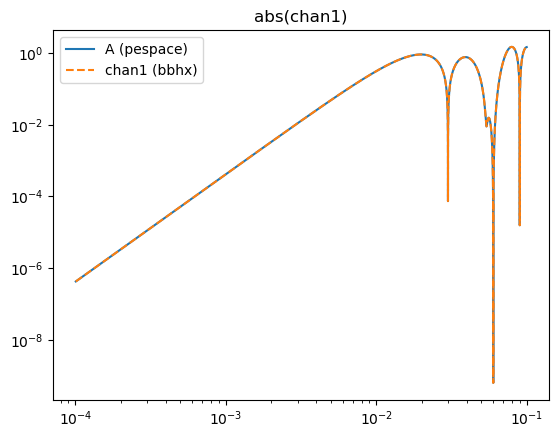

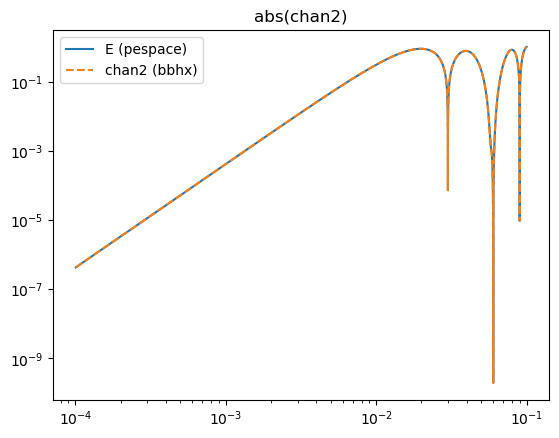

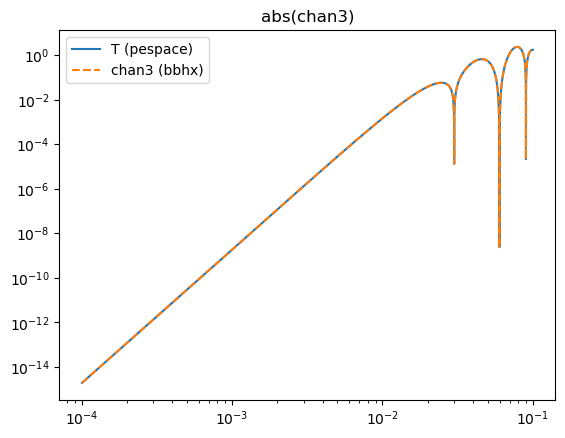

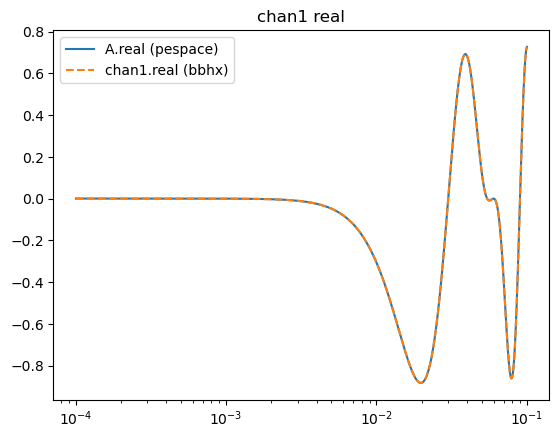

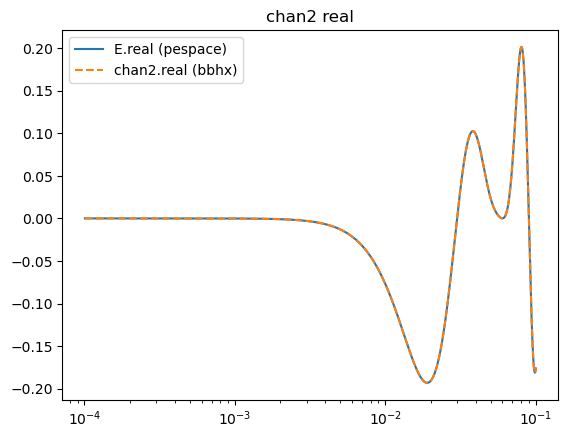

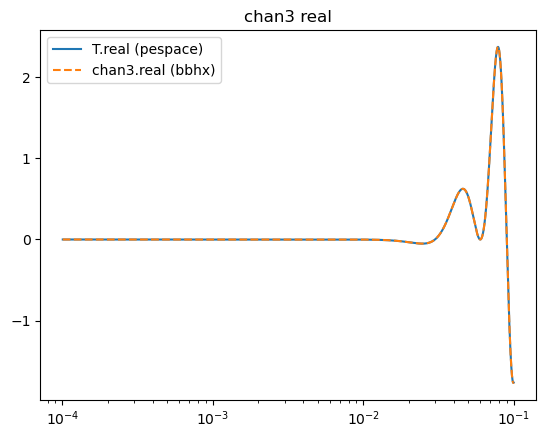

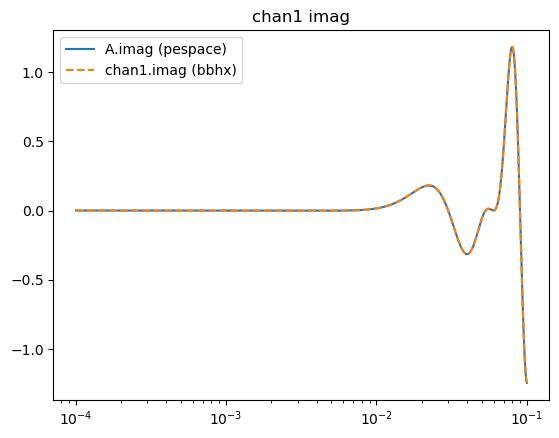

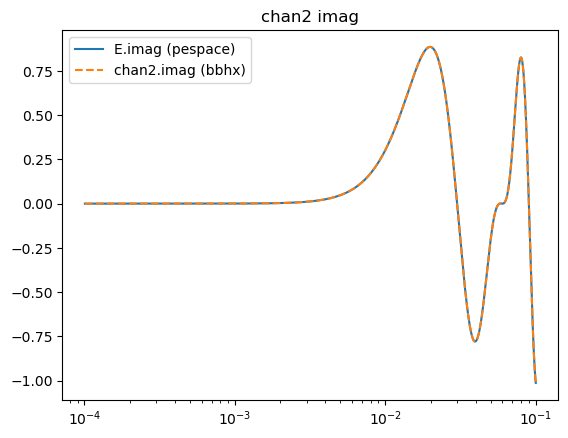

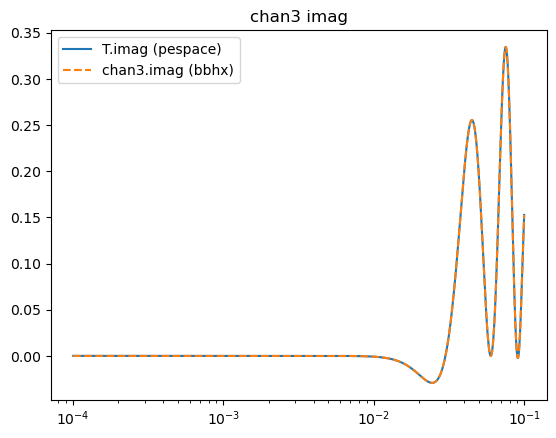

In [8]:
# abs
plt.figure()
plt.loglog(freqs, np.abs(chan1_pespace), label="A (pespace)")
plt.loglog(freqs, np.abs(chan1_bbhx), linestyle='dashed', label="chan1 (bbhx)")
plt.title("abs(chan1)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(chan2_pespace), label="E (pespace)")
plt.loglog(freqs, np.abs(chan2_bbhx), linestyle='dashed', label="chan2 (bbhx)")
plt.title("abs(chan2)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(chan3_pespace), label="T (pespace)")
plt.loglog(freqs, np.abs(chan3_bbhx), linestyle='dashed', label="chan3 (bbhx)")
plt.title("abs(chan3)")
plt.legend()

# real part
plt.figure()
plt.semilogx(freqs, chan1_pespace.real, label="A.real (pespace)")
plt.semilogx(freqs, chan1_bbhx.real, linestyle='dashed', label="chan1.real (bbhx)")
plt.title("chan1 real")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan2_pespace.real, label="E.real (pespace)")
plt.semilogx(freqs, chan2_bbhx.real, linestyle='dashed', label="chan2.real (bbhx)")
plt.title("chan2 real")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan3_pespace.real, label="T.real (pespace)")
plt.semilogx(freqs, chan3_bbhx.real, linestyle='dashed', label="chan3.real (bbhx)")
plt.title("chan3 real")
plt.legend()

# imag part
plt.figure()
plt.semilogx(freqs, -chan1_pespace.imag, label="A.imag (pespace)")
plt.semilogx(freqs, chan1_bbhx.imag, linestyle='dashed', label="chan1.imag (bbhx)")
plt.title("chan1 imag")
plt.legend()

plt.figure()
plt.semilogx(freqs, -chan2_pespace.imag, label="E.imag (pespace)")
plt.semilogx(freqs, chan2_bbhx.imag, linestyle='dashed', label="chan2.imag (bbhx)")
plt.title("chan2 imag")
plt.legend()

plt.figure()
plt.semilogx(freqs, -chan3_pespace.imag, label="T.imag (pespace)")
plt.semilogx(freqs, chan3_bbhx.imag, linestyle='dashed', label="chan3.imag (bbhx)")
plt.title("chan3 imag")
plt.legend()


### use a signal of GW from CBC

In [9]:
# waveform from bbhx
wf_gen_bbhx = PhenomHMAmpPhase(run_phenomd=True)
wf_gen_bbhx(
    params['mass_1'],
    params['mass_2'],
    params['chi_1'],
    params['chi_2'],
    params['luminosity_distance']*1e6*lal.PC_SI,
    0.0,
    f_peak_Hz,
    0.0,
    len(freqs),
    freqs=freqs,
    modes=[(2,2)], 
    direct=True,
)


In [10]:
# waveform from tiwave
params['reference_phase'] = 0.0
print(params)
waveform_tiw = IMRPhenomXAS(tdi_data.frequency_samples, f_peak_Hz, return_form='amplitude_phase')
waveform_tiw.update_waveform(params)

{'total_mass': 3000000.0, 'mass_ratio': 0.6, 'chi_1': 0.75, 'chi_2': 0.62, 'luminosity_distance': 56000.0, 'inclination': 0.4, 'reference_phase': 0.0, 'ecliptic_longitude': 1.375, 'ecliptic_latitude': -1.2108, 'polarization': 2.659, 'coalescence_time': 0.0, 'mass_1': 1875000.0, 'mass_2': 1125000.0, 'chirp_mass': 1256226.717491785, 'symmetric_mass_ratio': np.float64(0.234375)}


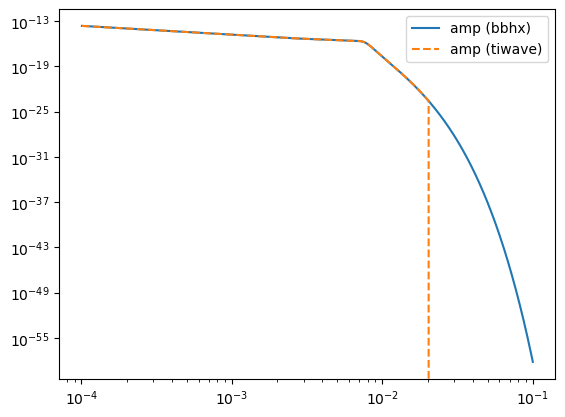

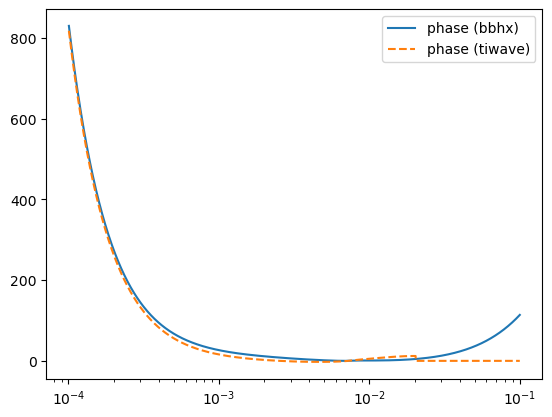

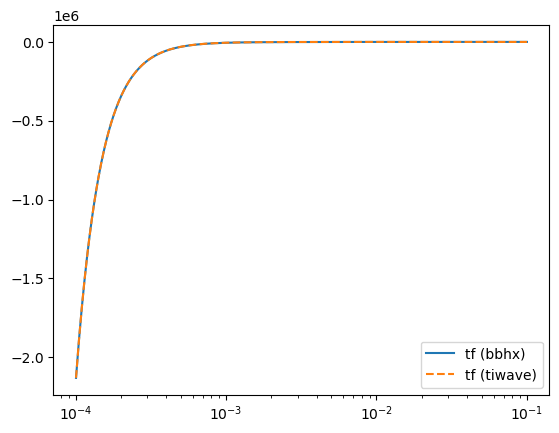

In [11]:
plt.figure()
plt.loglog(freqs, wf_gen_bbhx.amp[0][0], label='amp (bbhx)')
plt.loglog(freqs, waveform_tiw.waveform_container_numpy["amplitude"], linestyle='dashed', label='amp (tiwave)')
plt.legend()

plt.figure()
plt.semilogx(freqs, wf_gen_bbhx.phase[0][0], label='phase (bbhx)')
plt.semilogx(freqs, -waveform_tiw.waveform_container_numpy["phase"], linestyle='dashed', label='phase (tiwave)')
plt.legend()

plt.figure()
plt.semilogx(freqs, wf_gen_bbhx.tf[0][0], label='tf (bbhx)')
plt.semilogx(freqs, waveform_tiw.waveform_container_numpy["tf"], linestyle='dashed', label='tf (tiwave)')
plt.legend()

In [12]:
params['reference_phase'] = 1.3

response_bbhx = LISATDIResponse(TDItag="AET", tdi2=True)
# Note the phase differs by a conjugation due to the definition of FT
amp_phase = waveform_tiw.waveform_container_numpy

response_bbhx(
    freqs,
    params["inclination"],
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    np.pi / 2-params['reference_phase'],
    len(freqs),
    modes=[(2, 2)],
    phase=-amp_phase['phase'],
    tf=amp_phase['tf'],
    direct=True,
)
chan1_bbhx = response_bbhx.transferL1[0][0] * amp_phase['amplitude'] * np.exp(-1j*amp_phase['phase'])
chan2_bbhx = response_bbhx.transferL2[0][0] * amp_phase['amplitude'] * np.exp(-1j*amp_phase['phase'])
chan3_bbhx = response_bbhx.transferL3[0][0] * amp_phase['amplitude'] * np.exp(-1j*amp_phase['phase'])


In [13]:
waveform_tiw = IMRPhenomXAS(tdi_data.frequency_samples, f_peak_Hz)
waveform_tiw.update_waveform(params)
lisa_bbhx_convention.update_detector_response(
    waveform_tiw.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    0.0,
    )

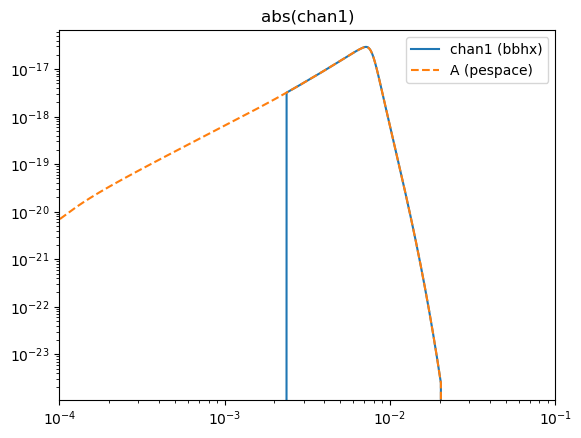

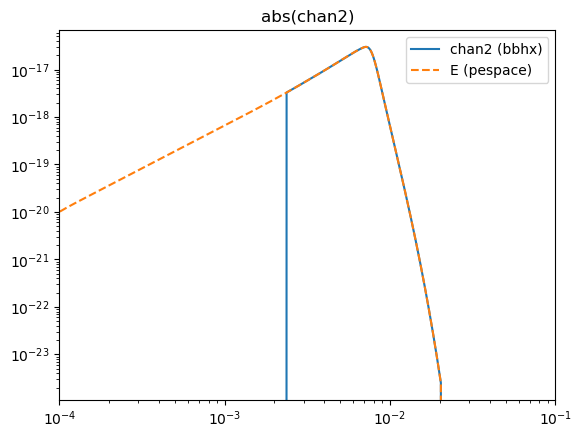

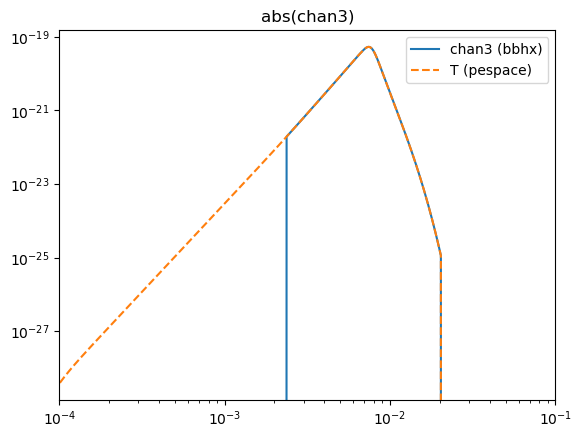

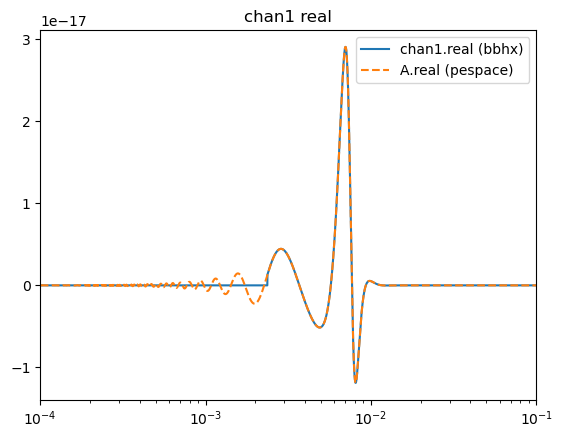

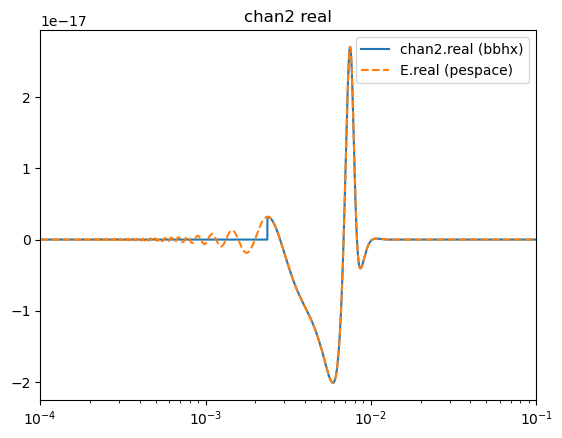

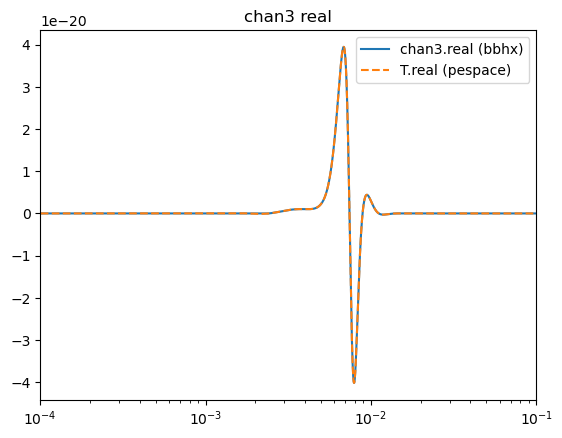

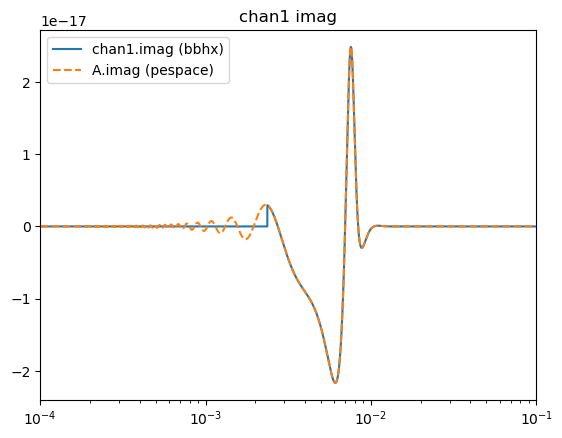

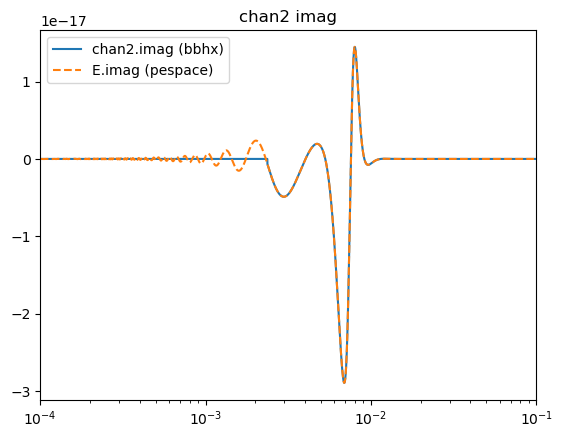

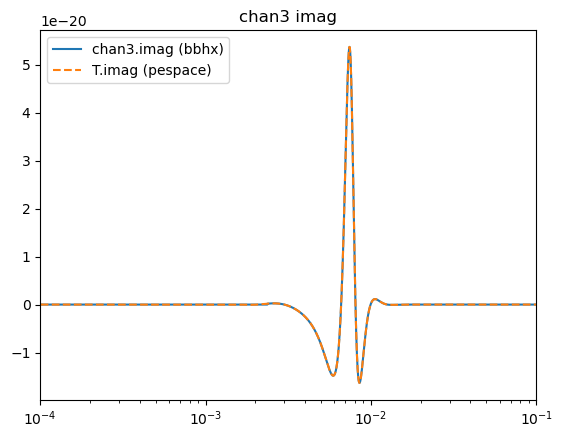

In [14]:
# abs
plt.figure()
plt.loglog(freqs, np.abs(chan1_bbhx), label="chan1 (bbhx)")
plt.loglog(freqs, np.abs(lisa_bbhx_convention.tdi_response_numpy["A"]), linestyle='dashed', label="A (pespace)")
plt.xlim(f_min, f_max)
plt.title("abs(chan1)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(chan2_bbhx), label="chan2 (bbhx)")
plt.loglog(freqs, np.abs(lisa_bbhx_convention.tdi_response_numpy["E"]), linestyle='dashed', label="E (pespace)")
plt.xlim(f_min, f_max)
plt.title("abs(chan2)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(chan3_bbhx), label="chan3 (bbhx)")
plt.loglog(freqs, np.abs(lisa_bbhx_convention.tdi_response_numpy["T"]), linestyle='dashed', label="T (pespace)")
plt.xlim(f_min, f_max)
plt.title("abs(chan3)")
plt.legend()

# real part
plt.figure()
plt.semilogx(freqs, chan1_bbhx.real, label="chan1.real (bbhx)")
plt.semilogx(freqs, lisa_bbhx_convention.tdi_response_numpy["A"].real, linestyle='dashed', label="A.real (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan1 real")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan2_bbhx.real, label="chan2.real (bbhx)")
plt.semilogx(freqs, lisa_bbhx_convention.tdi_response_numpy["E"].real, linestyle='dashed', label="E.real (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan2 real")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan3_bbhx.real, label="chan3.real (bbhx)")
plt.semilogx(freqs, lisa_bbhx_convention.tdi_response_numpy["T"].real, linestyle='dashed', label="T.real (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan3 real")
plt.legend()

# imag part
plt.figure()
plt.semilogx(freqs, chan1_bbhx.imag, label="chan1.imag (bbhx)")
plt.semilogx(freqs, -lisa_bbhx_convention.tdi_response_numpy["A"].imag, linestyle='dashed', label="A.imag (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan1 imag")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan2_bbhx.imag, label="chan2.imag (bbhx)")
plt.semilogx(freqs, -lisa_bbhx_convention.tdi_response_numpy["E"].imag, linestyle='dashed', label="E.imag (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan2 imag")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan3_bbhx.imag, label="chan3.imag (bbhx)")
plt.semilogx(freqs, -lisa_bbhx_convention.tdi_response_numpy["T"].imag, linestyle='dashed', label="T.imag (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan3 imag")
plt.legend()


### check the setting of coalescence time

tc:  524288.0
{'total_mass': 3000000.0, 'mass_ratio': 0.6, 'chi_1': 0.75, 'chi_2': 0.62, 'luminosity_distance': 56000.0, 'inclination': 0.4, 'reference_phase': 0.0, 'ecliptic_longitude': 1.375, 'ecliptic_latitude': -1.2108, 'polarization': 2.659, 'coalescence_time': np.float64(524288.0), 'mass_1': 1875000.0, 'mass_2': 1125000.0, 'chirp_mass': 1256226.717491785, 'symmetric_mass_ratio': np.float64(0.234375)}


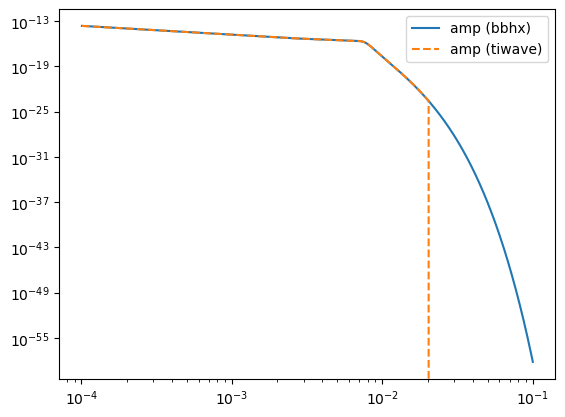

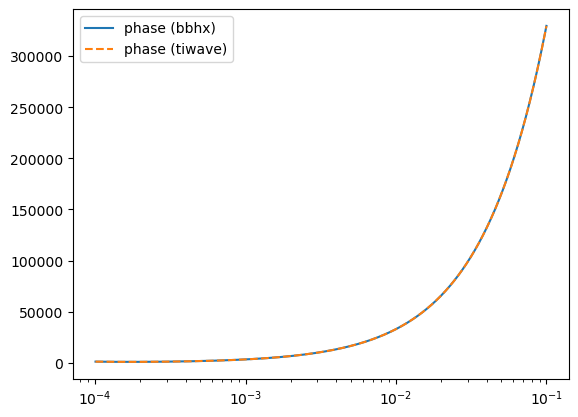

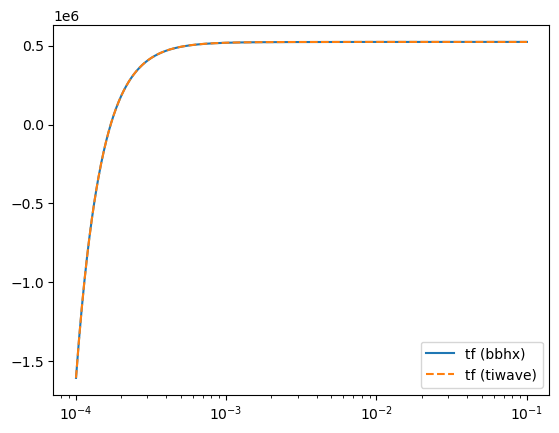

In [15]:
before_tc = 0.8 * duration
after_tc = 0.2 * duration
tc = t_start + before_tc
print("tc: ", tc)
params['coalescence_time'] = tc

# waveform from bbhx
wf_gen_bbhx = PhenomHMAmpPhase(run_phenomd=True)
wf_gen_bbhx(
    params['mass_1'],
    params['mass_2'],
    params['chi_1'],
    params['chi_2'],
    params['luminosity_distance']*1e6*lal.PC_SI,
    0.0,
    f_peak_Hz,
    params['coalescence_time'],
    len(freqs),
    freqs=freqs,
    modes=[(2,2)], 
    direct=True,
)

# waveform from tiwave
params['reference_phase'] = 0.0
print(params)
waveform_tiw = IMRPhenomXAS(tdi_data.frequency_samples, f_peak_Hz, return_form='amplitude_phase')
waveform_tiw.update_waveform(params)

# Note the phase differs by a conjugation due to the definition of FT
amp_phase = copy.deepcopy(waveform_tiw.waveform_container_numpy)
amp_phase['phase'] = -(amp_phase['phase'] - 2*np.pi*freqs*tc)
amp_phase['tf'] = amp_phase['tf'] + tc

plt.figure()
plt.loglog(freqs, wf_gen_bbhx.amp[0][0], label='amp (bbhx)')
plt.loglog(freqs, amp_phase['amplitude'], linestyle='dashed', label='amp (tiwave)')
plt.legend()

plt.figure()
plt.semilogx(freqs, wf_gen_bbhx.phase[0][0], label='phase (bbhx)')
plt.semilogx(freqs, amp_phase['phase'], linestyle='dashed', label='phase (tiwave)')
plt.legend()

plt.figure()
plt.semilogx(freqs, wf_gen_bbhx.tf[0][0], label='tf (bbhx)')
plt.semilogx(freqs, amp_phase['tf'], linestyle='dashed', label='tf (tiwave)')
plt.legend()

In [16]:
params['reference_phase'] = 1.3

response_bbhx = LISATDIResponse(TDItag="AET", tdi2=True)
response_bbhx(
    freqs,
    params["inclination"],
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    np.pi/2-params['reference_phase'],
    len(freqs),
    modes=[(2, 2)],
    phase=amp_phase['phase'],
    tf=amp_phase['tf'],
    direct=True,
    adjust_phase=False, # Note the input phase will be adjusted in-place by default!
)
chan1_bbhx = response_bbhx.transferL1[0][0] * amp_phase['amplitude'] * np.exp(1j*amp_phase['phase'])
chan2_bbhx = response_bbhx.transferL2[0][0] * amp_phase['amplitude'] * np.exp(1j*amp_phase['phase'])
chan3_bbhx = response_bbhx.transferL3[0][0] * amp_phase['amplitude'] * np.exp(1j*amp_phase['phase'])

waveform_tiw = IMRPhenomXAS(tdi_data.frequency_samples, f_peak_Hz)
waveform_tiw.update_waveform(params)
lisa_bbhx_convention.update_detector_response(
    waveform_tiw.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params['coalescence_time'],
    )

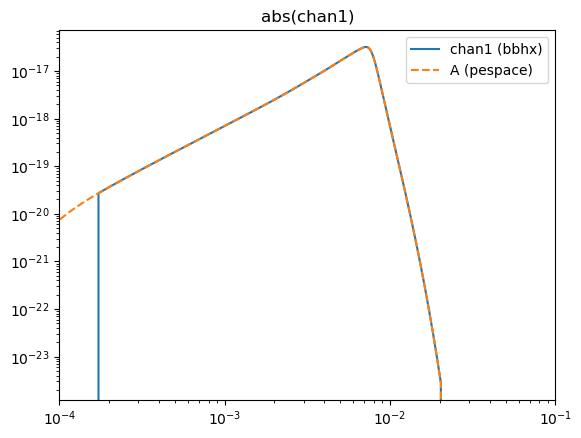

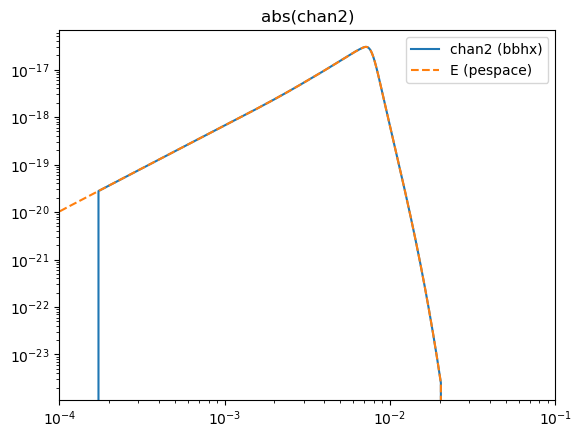

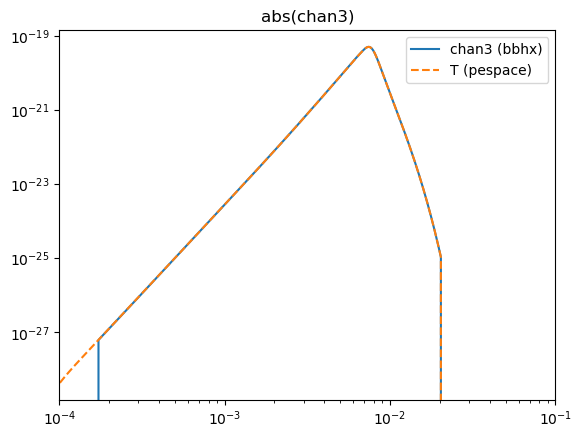

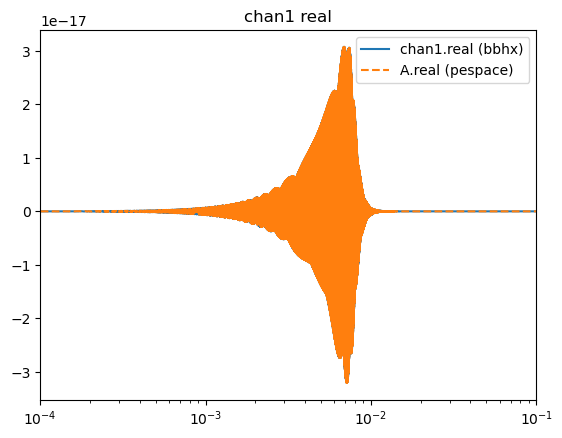

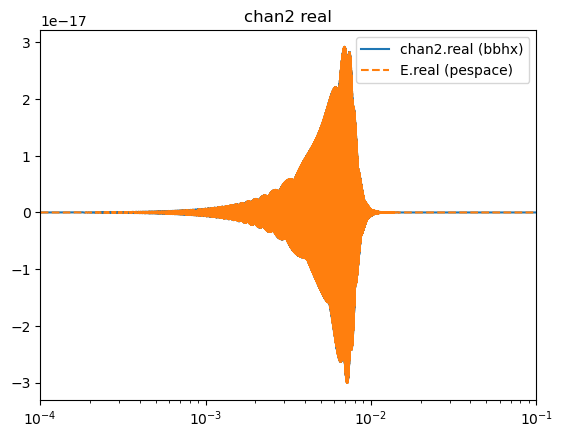

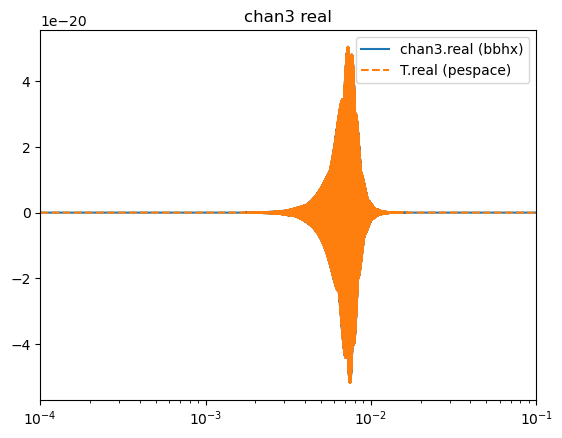

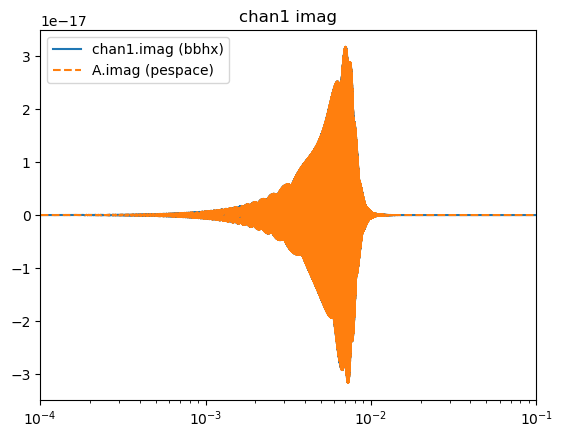

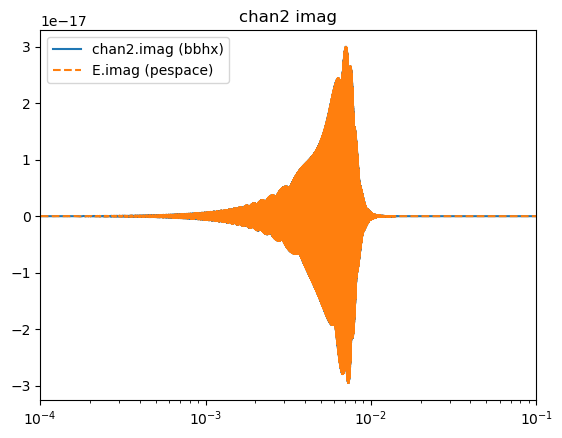

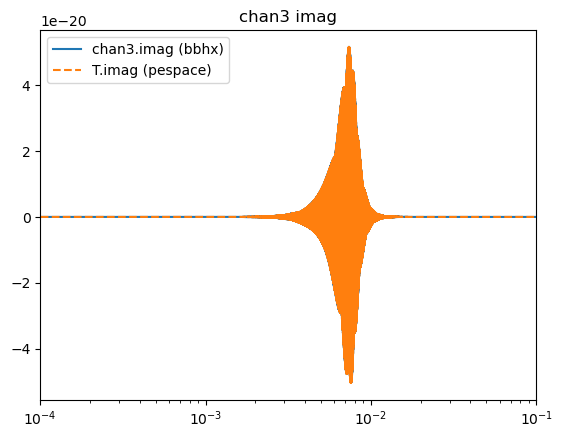

In [17]:
# abs
plt.figure()
plt.loglog(freqs, np.abs(chan1_bbhx), label="chan1 (bbhx)")
plt.loglog(freqs, np.abs(lisa_bbhx_convention.tdi_response_numpy["A"]), linestyle='dashed', label="A (pespace)")
plt.xlim(f_min, f_max)
plt.title("abs(chan1)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(chan2_bbhx), label="chan2 (bbhx)")
plt.loglog(freqs, np.abs(lisa_bbhx_convention.tdi_response_numpy["E"]), linestyle='dashed', label="E (pespace)")
plt.xlim(f_min, f_max)
plt.title("abs(chan2)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(chan3_bbhx), label="chan3 (bbhx)")
plt.loglog(freqs, np.abs(lisa_bbhx_convention.tdi_response_numpy["T"]), linestyle='dashed', label="T (pespace)")
plt.xlim(f_min, f_max)
plt.title("abs(chan3)")
plt.legend()

# real part
plt.figure()
plt.semilogx(freqs, chan1_bbhx.real, label="chan1.real (bbhx)")
plt.semilogx(freqs, lisa_bbhx_convention.tdi_response_numpy["A"].real, linestyle='dashed', label="A.real (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan1 real")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan2_bbhx.real, label="chan2.real (bbhx)")
plt.semilogx(freqs, lisa_bbhx_convention.tdi_response_numpy["E"].real, linestyle='dashed', label="E.real (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan2 real")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan3_bbhx.real, label="chan3.real (bbhx)")
plt.semilogx(freqs, lisa_bbhx_convention.tdi_response_numpy["T"].real, linestyle='dashed', label="T.real (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan3 real")
plt.legend()

# imag part
plt.figure()
plt.semilogx(freqs, chan1_bbhx.imag, label="chan1.imag (bbhx)")
plt.semilogx(freqs, -lisa_bbhx_convention.tdi_response_numpy["A"].imag, linestyle='dashed', label="A.imag (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan1 imag")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan2_bbhx.imag, label="chan2.imag (bbhx)")
plt.semilogx(freqs, -lisa_bbhx_convention.tdi_response_numpy["E"].imag, linestyle='dashed', label="E.imag (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan2 imag")
plt.legend()

plt.figure()
plt.semilogx(freqs, chan3_bbhx.imag, label="chan3.imag (bbhx)")
plt.semilogx(freqs, -lisa_bbhx_convention.tdi_response_numpy["T"].imag, linestyle='dashed', label="T.imag (pespace)")
plt.xlim(f_min, f_max)
plt.title("chan3 imag")
plt.legend()


/tmp/ipykernel_196071/3241018105.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(freqs, np.abs(np.conj(chan1_bbhx) - lisa_bbhx_convention.tdi_response_numpy["A"])/np.abs(chan1_bbhx), label="A rel_diff")
/tmp/ipykernel_196071/3241018105.py:3: RuntimeWarning: invalid value encountered in divide
  plt.loglog(freqs, np.abs(np.conj(chan1_bbhx) - lisa_bbhx_convention.tdi_response_numpy["A"])/np.abs(chan1_bbhx), label="A rel_diff")
/tmp/ipykernel_196071/3241018105.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(freqs, np.abs(np.conj(chan2_bbhx) - lisa_bbhx_convention.tdi_response_numpy["E"])/np.abs(chan2_bbhx), label="E rel_diff")
/tmp/ipykernel_196071/3241018105.py:9: RuntimeWarning: invalid value encountered in divide
  plt.loglog(freqs, np.abs(np.conj(chan2_bbhx) - lisa_bbhx_convention.tdi_response_numpy["E"])/np.abs(chan2_bbhx), label="E rel_diff")
/tmp/ipykernel_196071/3241018105.py:15: RuntimeWarning: divide by zero encountered in divide
 

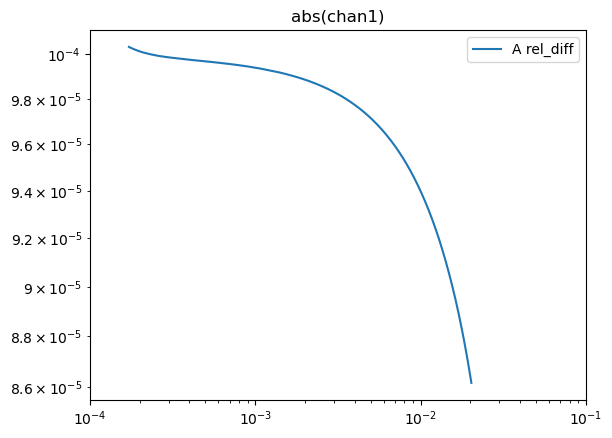

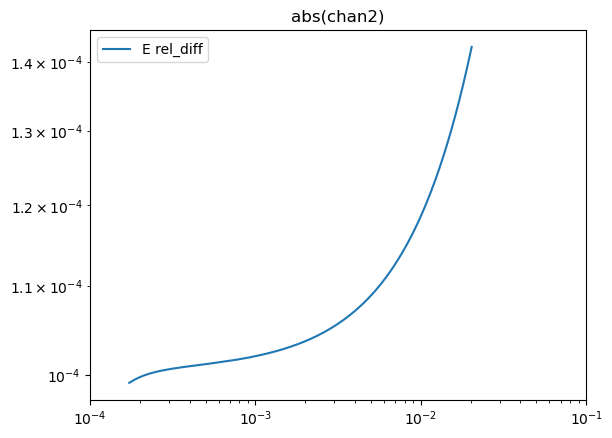

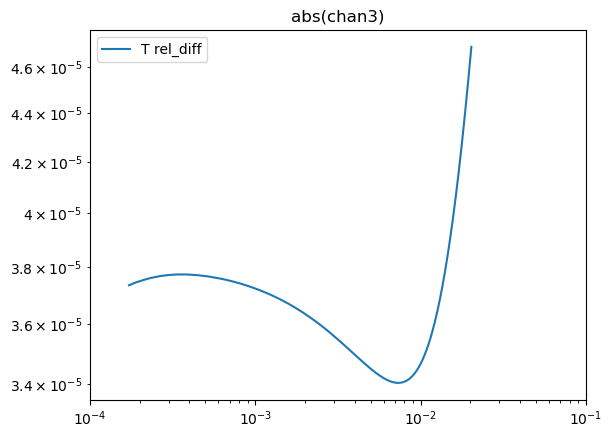

In [18]:
# abs
plt.figure()
plt.loglog(freqs, np.abs(np.conj(chan1_bbhx) - lisa_bbhx_convention.tdi_response_numpy["A"])/np.abs(chan1_bbhx), label="A rel_diff")
plt.xlim(f_min, f_max)
plt.title("abs(chan1)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(np.conj(chan2_bbhx) - lisa_bbhx_convention.tdi_response_numpy["E"])/np.abs(chan2_bbhx), label="E rel_diff")
plt.xlim(f_min, f_max)
plt.title("abs(chan2)")
plt.legend()

plt.figure()
plt.loglog(freqs, np.abs(np.conj(chan3_bbhx) - lisa_bbhx_convention.tdi_response_numpy["T"])/np.abs(chan3_bbhx), label="T rel_diff")
plt.xlim(f_min, f_max)
plt.title("abs(chan3)")
plt.legend()